# Bài 2: Dry Bean Dataset – Logistic Regression vs KNN

**Mục tiêu:** Xây dựng và so sánh 2 mô hình phân loại 7 loại hạt đậu (Dry Bean) dựa trên 16 đặc trưng hình học được trích xuất từ ảnh:

1. **Logistic Regression** (multiclass, dùng `multinomial`/`ovr` mặc định của sklearn)
2. **K-Nearest Neighbors (KNN)**

**Dữ liệu:** `dry_bean_train.csv` (10,834 mẫu) và `dry_bean_test.csv` (2,709 mẫu), đã được xử lý và chia sẵn từ `processing_seeds.ipynb` (train/test 80/20, `stratify` theo class, `random_state=42`, **chưa scale** để tránh data leakage — sẽ scale ở notebook này).

**Nguồn dữ liệu:** Koklu, M. and Ozkan, I.A. (2020). *Multiclass Classification of Dry Beans Using Computer Vision and Machine Learning Techniques.* Computers and Electronics in Agriculture, 174, 105507.

## 1. Import thư viện

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## 2. Đọc dữ liệu

Dữ liệu đã được `processing_seeds.ipynb` xử lý sẵn: chuẩn hóa tên cột, ép kiểu số, loại bỏ missing/duplicate, và chia train/test theo tỷ lệ 80/20 với `stratify` trên cột `class`. Ở đây ta chỉ cần đọc lại 2 file CSV kết quả.

In [6]:
train_df = pd.read_csv("Dry_Bean_Dataset/dry_bean_train.csv")
test_df = pd.read_csv("Dry_Bean_Dataset/dry_bean_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (10834, 17)
Test shape: (2709, 17)


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


In [7]:
# Kiểm tra nhanh: không còn missing values, đúng số cột như README mô tả (16 feature + 1 target)
print("Missing values (train):", train_df.isna().sum().sum())
print("Missing values (test):", test_df.isna().sum().sum())
print()
print("Các cột:", train_df.columns.tolist())
print("Số feature:", train_df.shape[1] - 1)

Missing values (train): 0
Missing values (test): 0

Các cột: ['area', 'perimeter', 'majoraxislength', 'minoraxislength', 'aspectration', 'eccentricity', 'convexarea', 'equivdiameter', 'extent', 'solidity', 'roundness', 'compactness', 'shapefactor1', 'shapefactor2', 'shapefactor3', 'shapefactor4', 'class']
Số feature: 16


## 3. Khám phá dữ liệu (EDA)

### 3.1. Phân bố lớp (class distribution)

Đây là bước quan trọng: nếu các lớp bị **mất cân bằng** (imbalanced), ta cần dùng `average="macro"` khi tính Precision/Recall/F1 thay vì `average="binary"`, và cần cẩn thận khi đọc Accuracy vì Accuracy có thể "ảo" khi một lớp chiếm đa số áp đảo.

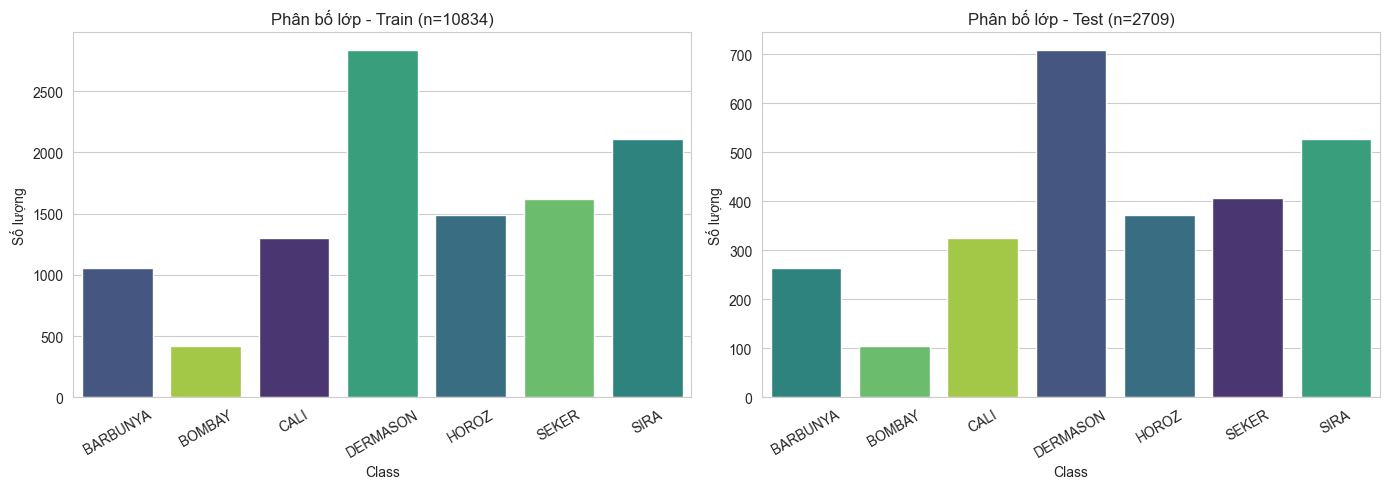

Tỷ lệ phần trăm mỗi lớp - Train:
class
BARBUNYA     9.76
BOMBAY       3.86
CALI        12.04
DERMASON    26.19
HOROZ       13.73
SEKER       14.96
SIRA        19.47
Name: proportion, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = sorted(train_df["class"].unique())

sns.countplot(data=train_df, x="class", order=order, ax=axes[0], hue="class", legend=False, palette="viridis")
axes[0].set_title(f"Phân bố lớp - Train (n={len(train_df)})")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Số lượng")
axes[0].tick_params(axis="x", rotation=30)

sns.countplot(data=test_df, x="class", order=order, ax=axes[1], hue="class", legend=False, palette="viridis")
axes[1].set_title(f"Phân bố lớp - Test (n={len(test_df)})")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Số lượng")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Tỷ lệ phần trăm mỗi lớp - Train:")
print((train_df["class"].value_counts(normalize=True).sort_index() * 100).round(2))

**Nhận xét:** Dữ liệu có **mất cân bằng lớp** khá rõ — `DERMASON` và `SIRA` chiếm tỷ trọng lớn, trong khi `BOMBAY` chỉ chiếm khoảng 3-4%. Tỷ lệ giữa train/test gần như giống hệt nhau nhờ `stratify` khi chia dữ liệu ở bước tiền xử lý, đảm bảo đánh giá mô hình công bằng trên cả 7 lớp.

### 3.2. Thống kê mô tả các đặc trưng

In [9]:
features = [c for c in train_df.columns if c != "class"]
train_df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
area,10834.0,53017.520214,29355.864916,20420.000000,36275.750000,44606.500000,61427.250000,248424.000000
perimeter,10834.0,854.636015,214.483912,524.736000,703.029500,793.880500,975.996250,1895.940000
majoraxislength,10834.0,319.786381,85.721678,183.601165,253.073094,296.522937,375.904362,726.373493
minoraxislength,10834.0,202.323863,45.048331,122.512653,175.856843,192.534047,217.071619,460.198497
aspectration,10834.0,1.580852,0.245198,1.024868,1.432105,1.549598,1.703029,2.430306
eccentricity,10834.0,0.750236,0.091892,0.218951,0.715832,0.763905,0.809450,0.911423
convexarea,10834.0,53736.119808,29803.051868,20684.000000,36678.000000,45131.500000,62397.000000,251082.000000
equivdiameter,10834.0,252.964273,59.273975,161.243764,214.913283,238.316512,279.663376,562.408446
extent,10834.0,0.749859,0.048726,0.555315,0.718752,0.759573,0.786785,0.866195
solidity,10834.0,0.987152,0.004665,0.919246,0.985675,0.988282,0.990017,0.994677


**Nhận xét:** Các đặc trưng có **thang đo (scale) rất khác nhau** — ví dụ `area` và `convexarea` có giá trị lên tới hàng chục nghìn đến hàng trăm nghìn, trong khi `eccentricity`, `extent`, `solidity`, `shapefactor1`-`4` chỉ nằm trong khoảng 0-1. Đây là lý do **bắt buộc phải chuẩn hóa (scale)** dữ liệu trước khi train, đặc biệt là với **KNN** — vốn dựa trên khoảng cách Euclid nên sẽ bị các đặc trưng có scale lớn (như `area`) chi phối hoàn toàn nếu không scale.

### 3.3. Tương quan giữa các đặc trưng

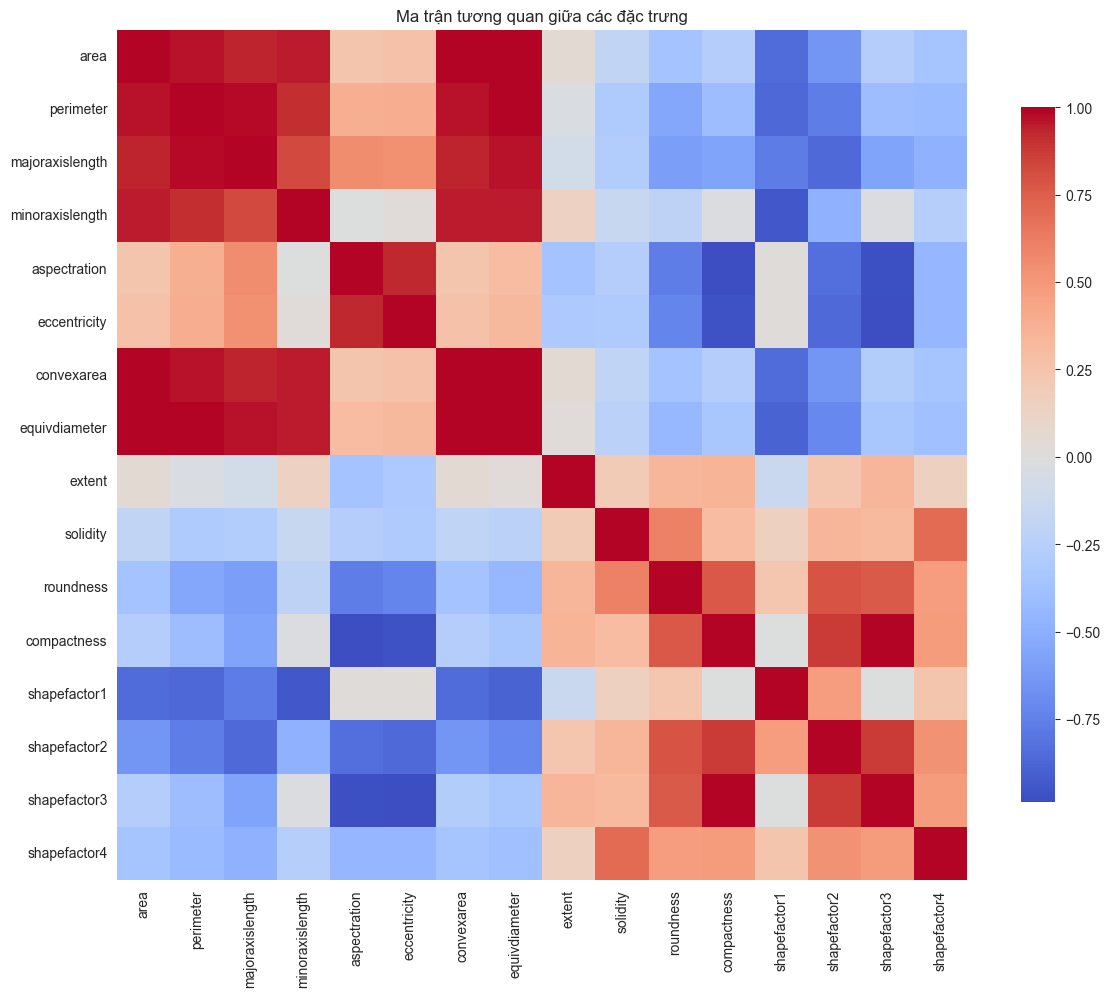

In [10]:
plt.figure(figsize=(12, 10))
corr = train_df[features].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, cbar_kws={"shrink": 0.8})
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.tight_layout()
plt.show()

**Nhận xét:** Nhiều đặc trưng có tương quan rất cao với nhau (ví dụ `area`, `perimeter`, `convexarea`, `equivdiameter` đều mô tả "kích thước" hạt đậu theo các cách khác nhau nên tương quan gần như tuyệt đối). Điều này là bình thường với đặc trưng hình học trích xuất từ ảnh, và cả Logistic Regression lẫn KNN đều không yêu cầu các đặc trưng độc lập tuyến tính để hoạt động, nên ta giữ nguyên toàn bộ 16 đặc trưng thay vì loại bớt.

### 3.4. Phân bố một số đặc trưng theo từng lớp

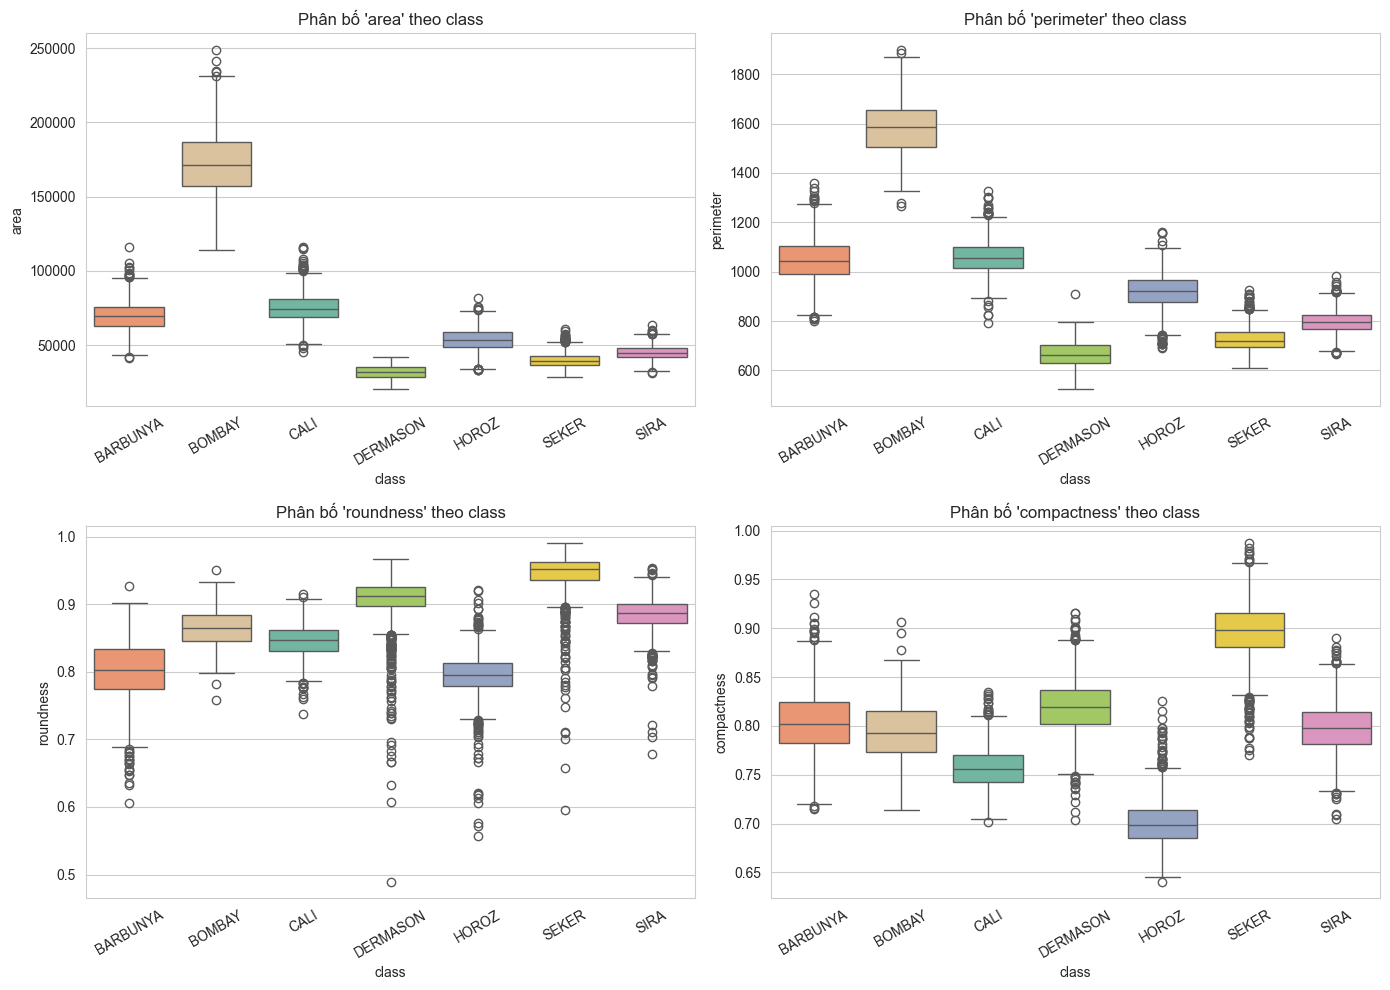

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sample_features = ["area", "perimeter", "roundness", "compactness"]

for ax, feat in zip(axes.flatten(), sample_features):
    sns.boxplot(data=train_df, x="class", y=feat, order=order, hue="class", legend=False, palette="Set2", ax=ax)
    ax.set_title(f"Phân bố '{feat}' theo class")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Nhận xét:** `BOMBAY` tách biệt rõ rệt khỏi các lớp còn lại về `area`/`perimeter` (hạt đậu Bombay lớn hơn hẳn), đây là lý do dễ hiểu vì sao lớp này thường được cả 2 mô hình phân loại gần như hoàn hảo (sẽ thấy ở phần đánh giá). Ngược lại, `roundness` và `compactness` của các lớp còn lại chồng lấn khá nhiều, cho thấy phân loại giữa 6 lớp còn lại (đặc biệt `SIRA` và `DERMASON`) sẽ khó hơn.

## 4. Tiền xử lý: Encode target & Scale features

- **Target (`class`):** dùng `LabelEncoder` để chuyển nhãn dạng chữ (`SEKER`, `BARBUNYA`, ...) thành số nguyên 0-6, vì `LogisticRegression` và `KNeighborsClassifier` của sklearn yêu cầu target dạng số.
- **Features:** dùng `StandardScaler`, **fit trên tập train, transform trên cả train và test** — đúng nguyên tắc tránh data leakage đã ghi chú trong `processing_seeds.ipynb` (không dùng thông tin từ tập test để tính mean/std).

In [12]:
X_train = train_df[features].copy()
y_train_raw = train_df["class"].copy()
X_test = test_df[features].copy()
y_test_raw = test_df["class"].copy()

# Encode target
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

print("Các lớp (theo thứ tự mã hóa 0-6):")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {i}: {cls}")

Các lớp (theo thứ tự mã hóa 0-6):
  0: BARBUNYA
  1: BOMBAY
  2: CALI
  3: DERMASON
  4: HOROZ
  5: SEKER
  6: SIRA


In [13]:
# Scale features - fit CHỈ trên train để tránh data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Sau khi scale - X_train:")
print("  Mean ~ 0:", np.round(X_train_scaled.mean(), 4))
print("  Std  ~ 1:", np.round(X_train_scaled.std(), 4))

Sau khi scale - X_train:
  Mean ~ 0: 0.0
  Std  ~ 1: 1.0


## 5. Mô hình 1: Logistic Regression

Vì đây là bài toán phân loại **đa lớp (7 lớp)**, `LogisticRegression` của sklearn sẽ tự động dùng chiến lược `multinomial` (softmax) cho solver mặc định `lbfgs`. Tăng `max_iter` lên 2000 để đảm bảo hội tụ (dữ liệu 16 chiều, ~10,834 mẫu train).

In [14]:
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)

print("Đã train xong Logistic Regression.")

Đã train xong Logistic Regression.


### 5.1. Đánh giá Logistic Regression

In [15]:
acc_lr = accuracy_score(y_test, y_pred_logreg)
prec_lr = precision_score(y_test, y_pred_logreg, average="macro")
rec_lr = recall_score(y_test, y_pred_logreg, average="macro")
f1_lr = f1_score(y_test, y_pred_logreg, average="macro")

print("=== Logistic Regression - Kết quả trên tập test ===")
print(f"Accuracy          : {acc_lr:.4f}")
print(f"Precision (macro) : {prec_lr:.4f}")
print(f"Recall (macro)    : {rec_lr:.4f}")
print(f"F1-score (macro)  : {f1_lr:.4f}")
print()
print("Classification report chi tiết theo từng lớp:")
print(classification_report(y_test, y_pred_logreg, target_names=label_encoder.classes_))

=== Logistic Regression - Kết quả trên tập test ===
Accuracy          : 0.9192
Precision (macro) : 0.9307
Recall (macro)    : 0.9300
F1-score (macro)  : 0.9302

Classification report chi tiết theo từng lớp:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



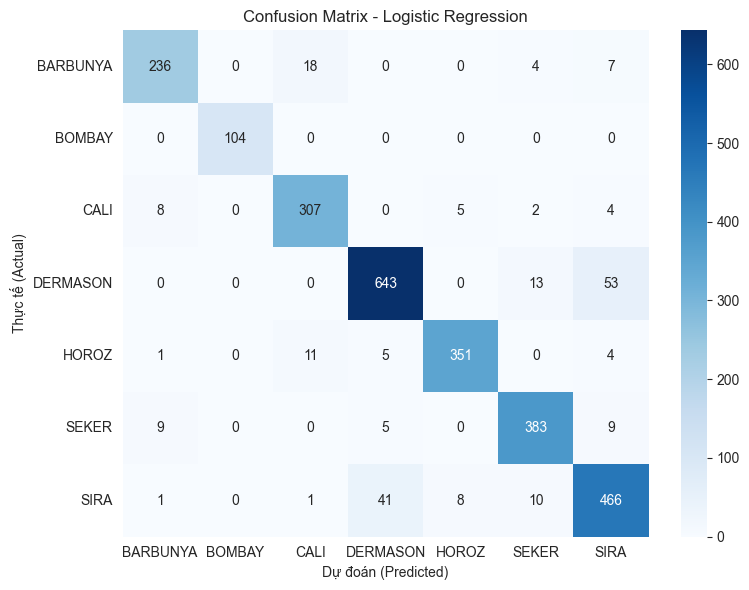

In [16]:
cm_lr = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (Actual)")
plt.tight_layout()
plt.show()

**Nhận xét:** `BOMBAY` được phân loại gần như hoàn hảo (đúng như dự đoán từ EDA vì đặc trưng kích thước tách biệt hẳn). Nhầm lẫn chủ yếu xảy ra giữa `SIRA` và `DERMASON` — hai lớp có `roundness`/`compactness` chồng lấn nhiều nhất trong biểu đồ boxplot ở trên.

## 6. Mô hình 2: K-Nearest Neighbors (KNN)

### 6.1. Tìm k tối ưu

KNN nhạy cảm với việc chọn số hàng xóm `k`. Ta thử nhiều giá trị `k` (1 đến 30) và chọn `k` cho **accuracy cao nhất trên tập test** để minh họa cách tuning tham số này. 

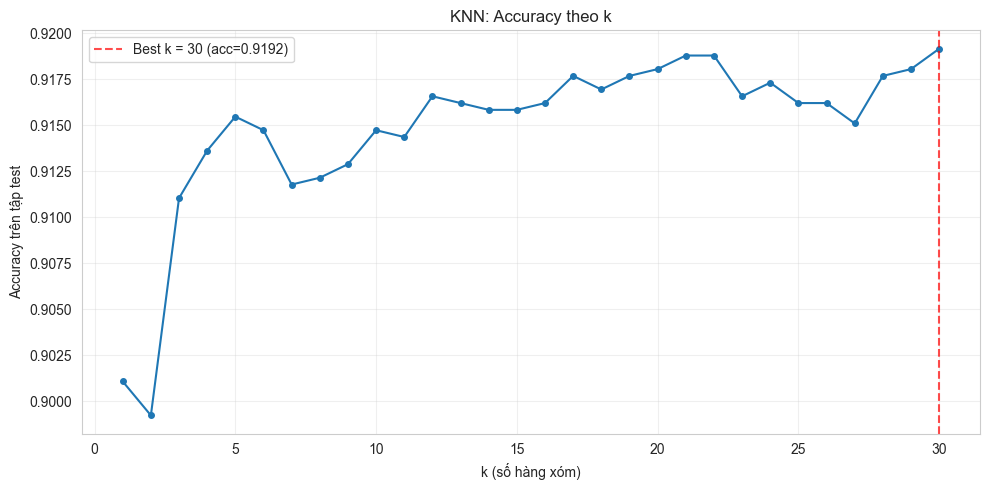

k tối ưu: 30, accuracy: 0.9192


In [17]:
k_range = range(1, 31)
k_accuracies = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    pred_temp = knn_temp.predict(X_test_scaled)
    k_accuracies.append(accuracy_score(y_test, pred_temp))

best_k = list(k_range)[int(np.argmax(k_accuracies))]
best_k_acc = max(k_accuracies)

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), k_accuracies, marker="o", markersize=4)
plt.axvline(best_k, color="red", linestyle="--", alpha=0.7, label=f"Best k = {best_k} (acc={best_k_acc:.4f})")
plt.xlabel("k (số hàng xóm)")
plt.ylabel("Accuracy trên tập test")
plt.title("KNN: Accuracy theo k")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"k tối ưu: {best_k}, accuracy: {best_k_acc:.4f}")

**Nhận xét:** Đường cong khá "phẳng" — accuracy dao động rất ít (~0.90 đến ~0.92) khi `k` từ 12 trở lên, nghĩa là mô hình **không quá nhạy với việc chọn k** một khi `k` đủ lớn để tránh nhiễu (k=1, k=2 dễ overfit vào từng điểm dữ liệu lẻ tẻ nên accuracy thấp hơn rõ rệt so với các k lớn hơn).

### 6.2. Train KNN với k tối ưu và đánh giá

In [18]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average="macro")
rec_knn = recall_score(y_test, y_pred_knn, average="macro")
f1_knn = f1_score(y_test, y_pred_knn, average="macro")

print(f"=== KNN (k={best_k}) - Kết quả trên tập test ===")
print(f"Accuracy          : {acc_knn:.4f}")
print(f"Precision (macro) : {prec_knn:.4f}")
print(f"Recall (macro)    : {rec_knn:.4f}")
print(f"F1-score (macro)  : {f1_knn:.4f}")
print()
print("Classification report chi tiết theo từng lớp:")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

=== KNN (k=30) - Kết quả trên tập test ===
Accuracy          : 0.9192
Precision (macro) : 0.9331
Recall (macro)    : 0.9287
F1-score (macro)  : 0.9306

Classification report chi tiết theo từng lớp:
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.88      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.95      0.93       326
    DERMASON       0.92      0.92      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.85      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



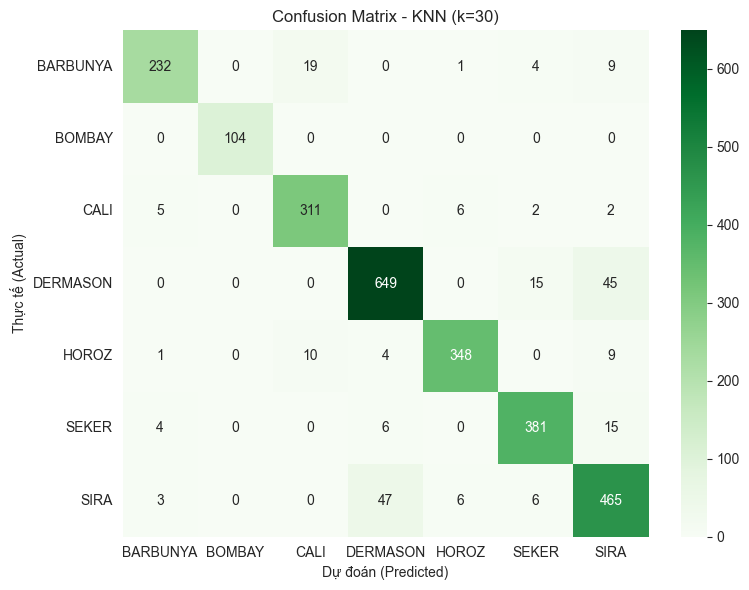

In [19]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix - KNN (k={best_k})")
plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (Actual)")
plt.tight_layout()
plt.show()

**Nhận xét:** Pattern nhầm lẫn của KNN gần giống Logistic Regression — vẫn tập trung ở cặp `SIRA`/`DERMASON`, và `BOMBAY` vẫn được phân loại gần như tuyệt đối. Điều này hợp lý vì cả 2 mô hình đều học trên cùng một không gian đặc trưng đã scale, và ranh giới quyết định giữa các lớp phần lớn phản ánh cấu trúc thật của dữ liệu chứ không phải đặc thù riêng của thuật toán.

## 7. So sánh Logistic Regression vs KNN

In [20]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", f"KNN (k={best_k})"],
    "Accuracy": [acc_lr, acc_knn],
    "Precision (macro)": [prec_lr, prec_knn],
    "Recall (macro)": [rec_lr, rec_knn],
    "F1-score (macro)": [f1_lr, f1_knn],
})

comparison_df.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,Logistic Regression,0.9192,0.9307,0.9300,0.9302
1,KNN (k=30),0.9192,0.9331,0.9287,0.9306


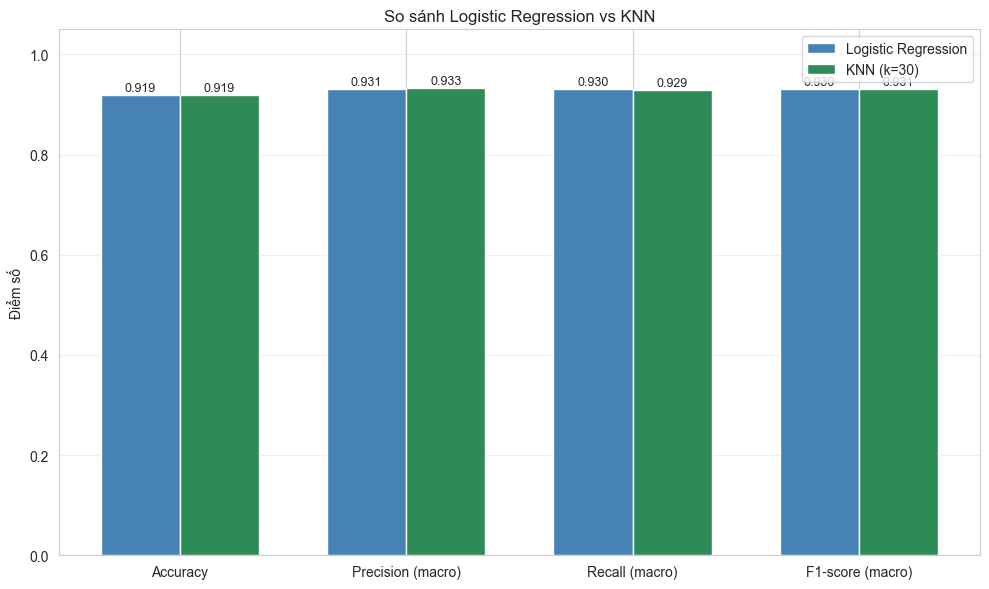

In [21]:
metrics = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_lr = ax.bar(x - width/2, comparison_df.loc[0, metrics], width, label="Logistic Regression", color="steelblue")
bars_knn = ax.bar(x + width/2, comparison_df.loc[1, metrics], width, label=f"KNN (k={best_k})", color="seagreen")

ax.set_ylabel("Điểm số")
ax.set_title("So sánh Logistic Regression vs KNN")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [bars_lr, bars_knn]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Nhận xét tổng kết

- **Hiệu năng gần như tương đương:** Cả hai mô hình đều đạt accuracy ~92% và F1-macro ~0.93 trên tập test — chênh lệch giữa hai mô hình chỉ trong khoảng 0.1-0.2 điểm phần trăm, không đáng kể về mặt thống kê với kích thước tập test này (2,709 mẫu).
- **Logistic Regression** có ưu thế về mặt **thực dụng**: train nhanh hơn nhiều (KNN phải lưu toàn bộ tập train và tính khoảng cách tới từng điểm khi dự đoán — tốn nhiều tài nguyên hơn ở bước inference, đặc biệt khi dữ liệu lớn), mô hình đơn giản hơn để triển khai, và cho phép diễn giải được (hệ số hồi quy thể hiện mức độ ảnh hưởng của từng đặc trưng).
- **KNN** cần thêm bước tuning `k`, nhạy cảm với `k` nhỏ (overfit) hoặc dữ liệu nhiễu, và tốn chi phí tính toán tại thời điểm dự đoán tỷ lệ thuận với kích thước tập train.
- **Cả hai** đều gặp khó khăn tương tự nhau ở cặp lớp `SIRA`/`DERMASON` — đây là giới hạn đến từ bản chất dữ liệu (2 loại hạt có hình dạng thực sự giống nhau) chứ không phải nhược điểm riêng của một thuật toán cụ thể.
- **Kết luận:** Với bộ dữ liệu Dry Bean này, **Logistic Regression là lựa chọn hợp lý hơn** nhờ hiệu năng tương đương nhưng chi phí tính toán và triển khai thấp hơn đáng kể so với KNN, đặc biệt khi cần dự đoán trên khối lượng dữ liệu lớn trong thực tế (ví dụ hệ thống phân loại hạt đậu tự động theo thời gian thực).